In [ ]:
import getpass
import os

os.environ["AZURE_OPENAI_API_KEY"] = "<key>"
os.environ["AZURE_OPENAI_ENDPOINT"] = "https://ai-engineering-vidvatta1.openai.azure.com/"
os.environ["AZURE_DEPLOYMENT"]="gpt-5.4-mini"  # or your deployment
os.environ["API_VERSION"]="2025-04-01-preview"

In [ ]:
! pip install langchain langgraph langchain-openai -qU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    azure_deployment=os.environ["AZURE_DEPLOYMENT"],  # or your deployment
    api_version=os.environ["API_VERSION"])

llm.invoke('hello')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 7, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DThO8wmlCtldgNngizwA19AwwGsLd', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'pr

In [ ]:
from langchain.agents import create_agent
from langgraph.prebuilt import InjectedState

bank_balance = {
  "8": 10000,
  "9": 6500
}

def get_bank_balance(user_id: str):
  """Tool providing bank balance of user"""
  balance = bank_balance.get(user_id)
  return f"Bank balance is {balance}"

def withdraw_amount(amount: int, user_id: str):
  """Tool to withdraw given amount"""
  balance = bank_balance.get(user_id)
  if balance >= amount:
    bank_balance[user_id] = balance - amount
    return f"Withdrawn {amount}. Remaining balance is {bank_balance[user_id]}"
  else:
    return "Insufficient balance"

banking_agent = create_agent(llm,
  tools=[get_bank_balance, withdraw_amount],
  system_prompt="You are a banking assistant. You can provide bank balance and withdraw amount for the user. After withdraw always use bank balance to see remaning balance")


In [ ]:
from typing import Annotated, Literal, Sequence, TypedDict, Any
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    agent_trace: Sequence[BaseMessage]


def input_check_node(state: AgentState):
  print('input_check_node called')
  return state

def get_banking_agents_response(state: AgentState):
  print('get_banking_agents_response called')
  query = state['messages']#[-1]
  response = banking_agent.invoke({
    'messages': query
  })
  return {'messages': [response['messages'][-1]], 'agent_trace': response}

def output_sanitize_node(state: AgentState):
  print('output_sanitize_node called')
  return state

In [ ]:
def decision_node(state: AgentState):
  user_query = state['messages'][-1]
  response = llm.invoke(f"""
  for a given user query check if it is related to bank balance and withdrawal or not.
  if yes, return only yes otherwise no, answer should be only yes or no

  user query : {user_query}
  """)
  print(response)
  if response.content.lower() == 'yes':
    return 'agentnode'
  else:
    return 'end'



In [ ]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node('input_check_node', input_check_node)
graph_builder.add_node('get_banking_agents_response', get_banking_agents_response)
graph_builder.add_node('output_sanitize_node', output_sanitize_node)

graph_builder.add_edge(START, 'input_check_node')
graph_builder.add_conditional_edges('input_check_node', decision_node, {'agentnode': 'get_banking_agents_response', 'end': END})
# graph_builder.add_edge('input_check_node', 'get_banking_agents_response')
graph_builder.add_edge('get_banking_agents_response', 'output_sanitize_node')

In [ ]:
! pip install -q langgraph-checkpoint-sqlite

from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

conn = sqlite3.connect("checkpoints_langgraph1.sqlite", check_same_thread=False)

sqlite_checkpointer = SqliteSaver(conn)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 6.0 MB/s eta 0:00:00


In [ ]:
graph = graph_builder.compile(checkpointer=sqlite_checkpointer)

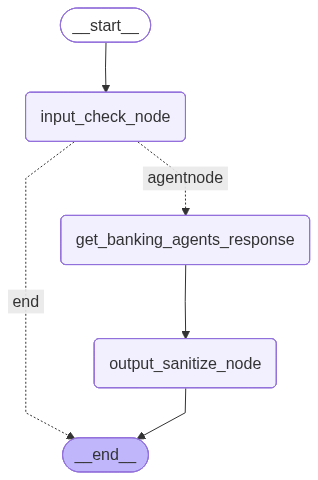

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
config = {"configurable": {"thread_id": "1"}}

graph.invoke({
    'messages': ['what is my bank balance for user 8']
}, config)

input_check_node called
content='yes' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 5, 'prompt_tokens': 90, 'total_tokens': 95, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DThWiTut0mKVWCrfC5SCIJywx8pKi', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_

{'messages': [HumanMessage(content='what is my bank balance', additional_kwargs={}, response_metadata={}, id='80941275-b370-406e-ab76-8b1688bd0ee4'),
  AIMessage(content='Your bank balance is currently unavailable (`None`).', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 225, 'total_tokens': 238, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DThWNE7pGMnBj7nmtGgpzlwxdLDs0', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_code': {'detected': False, 'filtered': False}, 'protected_material

In [ ]:
graph.invoke({
    'messages': ['withdraw 2000 and provide new balance for user 8']
}, config)

input_check_node called
content='yes' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 5, 'prompt_tokens': 97, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DThXMnPEpYl09fyKeWDAL5qOjbNTb', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material

{'messages': [HumanMessage(content='what is my bank balance', additional_kwargs={}, response_metadata={}, id='80941275-b370-406e-ab76-8b1688bd0ee4'),
  AIMessage(content='Your bank balance is currently unavailable (`None`).', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 225, 'total_tokens': 238, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DThWNE7pGMnBj7nmtGgpzlwxdLDs0', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_code': {'detected': False, 'filtered': False}, 'protected_material

In [ ]:
## Long Term Memory

In [ ]:
from langchain_openai import AzureOpenAIEmbeddings

embeddings = AzureOpenAIEmbeddings(
    model="text-embedding-3-large",
)

In [ ]:
from langgraph.store.memory import InMemoryStore
import uuid

in_memory_store = InMemoryStore()
store = InMemoryStore(index={"embed": embeddings})

In [ ]:
user_id = "1"
namespace_for_memory = (user_id, 'food')

store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"food_preference": "I love Italian cuisine", "context": "Discussing dinner plans"},
)

store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"food_preference": "I hate chinese", "context": "Discussing lunch plans"},
)

store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"food_preference": "I like hyderabad biryani", "context": "Discussing breakf plans"},
)

store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"food_preference": "I like masala dosa", "context": "Discussing dinner plans"},
)

In [ ]:
# 26. Search Store
memories = store.search(
    namespace_for_memory,
    query="foods i dont like",
    limit=2
)
for memory in memories:
  print(memory.value)

{'food_preference': 'I hate chinese', 'context': 'Discussing lunch plans'}
{'food_preference': 'I like hyderabad biryani', 'context': 'Discussing breakf plans'}


In [ ]:
user_id = "1"
namespace_for_memory = (user_id, 'banking')

store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"risk_apetite": "I like lower risk"},
)

# 25. Add to Store
store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"age": "25", "profession": "software engineer"},
)

# 25. Add to Store
store.put(
    namespace_for_memory,
    str(uuid.uuid4()),
    {"financial free goal": "40 years"},
)

In [ ]:
ages = [34,5345,6456,435]
ages[:-1]

[34, 5345, 6456]

In [ ]:
from langchain.messages import HumanMessage

def input_check_node(state: AgentState):
  user_query = state['messages'][-1]

  memories = store.search(
      namespace_for_memory,
      query=user_query.content,
      limit=2
  )

  long_term_memory_scan = [str(memory.value) for memory in memories]

  new_context = f"{user_query} \n context from long term memory: {long_term_memory_scan}"
  print(new_context)

  messages = state['messages'][:-1] + [HumanMessage(content=new_context)]

  print('input_check_node called')
  return {'messages': messages}


def put_relavent_long_term_memory(state: AgentState):
  user_query = state['messages'][-1]

  response = llm.invoke(f"""
  for long term reference, lets identify if user is talking about any type of  financial preferences about accounts, or limits or certain special instructions, if yes, then summarize and return the preference in short and crisp manner
  if there is no preference, just return a blank string without any content

  User Query: {user_query}
  """)
  print('Relevant memory', response)
  if response.content != "":
    store.put(
      namespace_for_memory,
      str(uuid.uuid4()),
      {'financial_preferences': response.content}
    )
  return state

In [ ]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node('input_check_node', input_check_node)
graph_builder.add_node('put_relavent_long_term_memory', put_relavent_long_term_memory)
graph_builder.add_node('get_banking_agents_response', get_banking_agents_response)
graph_builder.add_node('output_sanitize_node', output_sanitize_node)

graph_builder.add_edge(START, 'input_check_node')
graph_builder.add_edge(START, 'put_relavent_long_term_memory')
graph_builder.add_edge('input_check_node', 'get_banking_agents_response')
graph_builder.add_edge('get_banking_agents_response', 'output_sanitize_node')

In [ ]:
graph = graph_builder.compile(checkpointer=sqlite_checkpointer)

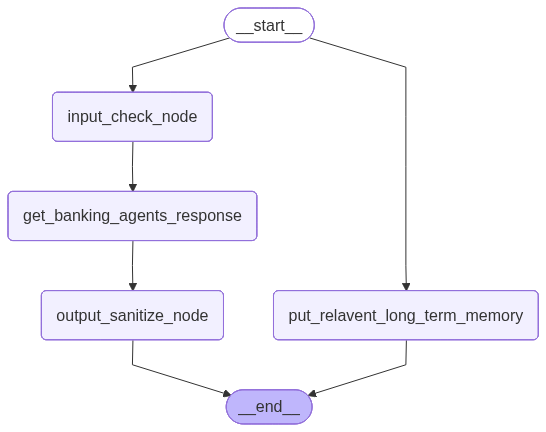

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
config = {"configurable": {"thread_id": "2"}}

graph.invoke({
    'messages': ['what is my risk apetite']
}, config)

content='what is my risk apetite' additional_kwargs={} response_metadata={} id='84047837-dc75-4da2-a5c9-80408e4c22ac' 
 context from long term memory: ["{'risk_apetite': 'I like lower risk'}", "{'financial free goal': '40 years'}"]
input_check_node called
content='risk appetite' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 112, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DTiEq5k9gIVEIpFW6IUv95w7thbeM', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 's

{'messages': [HumanMessage(content='what is my risk apetite', additional_kwargs={}, response_metadata={}, id='84047837-dc75-4da2-a5c9-80408e4c22ac'),
  HumanMessage(content='content=\'what is my risk apetite\' additional_kwargs={} response_metadata={} id=\'84047837-dc75-4da2-a5c9-80408e4c22ac\' \n context from long term memory: ["{\'risk_apetite\': \'I like lower risk\'}", "{\'financial free goal\': \'40 years\'}"]', additional_kwargs={}, response_metadata={}, id='01d8b2a7-7911-4143-8aec-0d85f88208fd'),
  AIMessage(content='Based on your memory, your risk appetite is **lower risk**.\n\nIf you want, I can also help explain what that means for investing or banking decisions.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 266, 'total_tokens': 302, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_toke

In [ ]:
config = {"configurable": {"thread_id": "3"}}

graph.invoke({
    'messages': ['I would like to buy a house with my financial savings']
}, config)

content='I would like to buy a house with my financial savings' additional_kwargs={} response_metadata={} id='cd7ee1ec-04d5-4bc4-be55-fc5d37f08689' 
 context from long term memory: ["{'financial free goal': '40 years'}", "{'financial_preferences': 'risk appetite'}"]
input_check_node called
Relevant memory content='{"preference": "Buy a house with financial savings"}' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 118, 'total_tokens': 134, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DTiGWKgyVgyHFAukaeVfk3TkZxHEG', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'det

{'messages': [HumanMessage(content='I would like to buy a house with my financial savings', additional_kwargs={}, response_metadata={}, id='cd7ee1ec-04d5-4bc4-be55-fc5d37f08689'),
  HumanMessage(content='content=\'I would like to buy a house with my financial savings\' additional_kwargs={} response_metadata={} id=\'cd7ee1ec-04d5-4bc4-be55-fc5d37f08689\' \n context from long term memory: ["{\'financial free goal\': \'40 years\'}", "{\'financial_preferences\': \'risk appetite\'}"]', additional_kwargs={}, response_metadata={}, id='7dcdf694-ad57-4b23-a10d-e1a46f7c1bbc'),
  AIMessage(content='Buying a house is a big goal. I can help you check your savings balance first and then see whether you may be ready to use it toward a home purchase.\n\nIf you want, I can:\n1. Check your bank balance\n2. Help estimate how much house you might afford\n3. Discuss a simple savings plan toward the goal\n\nIf you’d like me to check your balance, please share your user ID.', additional_kwargs={'refusal': No

In [ ]:
config = {"configurable": {"thread_id": "4"}}

graph.invoke({
    'messages': ['Do I have any Preferences with respect to my financial savings']
}, config)

content='Do I have any Preferences with respect to my financial savings' additional_kwargs={} response_metadata={} id='9339727f-1ea2-4f0a-818d-905204605499' 
 context from long term memory: ['{\'financial_preferences\': \'{"preference": "Buy a house with financial savings"}\'}', "{'financial_preferences': 'risk appetite'}"]
input_check_node called
Relevant memory content='Savings preference mentioned.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 116, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DTiHIHa1axaydxLR0BcQc6xk7UFbJ', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'sev

{'messages': [HumanMessage(content='Do I have any Preferences with respect to my financial savings', additional_kwargs={}, response_metadata={}, id='9339727f-1ea2-4f0a-818d-905204605499'),
  HumanMessage(content='content=\'Do I have any Preferences with respect to my financial savings\' additional_kwargs={} response_metadata={} id=\'9339727f-1ea2-4f0a-818d-905204605499\' \n context from long term memory: [\'{\\\'financial_preferences\\\': \\\'{"preference": "Buy a house with financial savings"}\\\'}\', "{\'financial_preferences\': \'risk appetite\'}"]', additional_kwargs={}, response_metadata={}, id='92325c89-250d-401a-b163-79b78727da17'),
  AIMessage(content='Yes — from the information I have, your financial savings preference appears to be:\n\n- **Primary goal:** **Buy a house** with your savings\n- **Also noted:** **Risk appetite** as a financial preference\n\nIf you want, I can help you refine these into a clearer savings plan.', additional_kwargs={'refusal': None}, response_metada

In [ ]:
## MCP